In [1]:
import numpy as np
import trimesh
import pandas as pd

import json
import ast

import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from functions.stent_funcs import (compute_pre_stent_size_ratio,
                                   preprocess_stent, segment_stent,
                                   open_stent_to_plane,
                                   compute_skeleton_2d,
                                   check_skeleton_quality, remove_bad_connections,
                                   tune_skeleton_params, plot_skeleton_quality,
                                   adjust_skeleton_to_local_midsurface,
                                   analyze_skeleton_connectivity,
                                   reconnect_skeleton_endpoints,
                                   prune_skeleton_spurs, _write_skeleton_stp)


In [2]:
def stent_skeleton(
    stent_stl_file: str,
    auto_tune: bool,              # penalty-driven tuner for pixels_per_strut / dilate_px
    tune_time_limit: float,       # tuner wall-clock cap (s)
    pixels_per_strut: int,        # raster resolution (start value when auto_tune)
    dilate_px: int,               # raster dilation radius (start value when auto_tune)
    pad_fraction: float,          # seam-replication margin for the unrolled raster
    override_n_samples: int,
    segmentation_wanted: bool,
    small_logic: str,             # 'or' / 'and' — segment_stent small-fragment combine rule
    remove_supports: bool,
    plot_thickness_calc: bool,
    plot_segmentation: bool,
    plot_skeleton: bool,
    reconnect_endpoints: bool = True,       # bridge spurious degree-1 breaks
    reconnect_max_gap_factor: float = 12.0, # max bridgeable gap = factor * pixel_size
    prune_spurs: bool = True,               # delete short non-tip dead-end twigs
    prune_tip_frac: float = 0.05,           # axial tip band as fraction of z-span
    prune_max_spur_len: float = None,       # optional spur length cap (mm); None = no cap
) -> dict:
    """Complete pipeline from STL to adjusted 3D skeleton points.

    The stent surface is segmented into locally pipe-like regions (segment_stent
    with valley-threshold merge of small fragments), then rasterised and
    skeletonised on the unrolled (arc, z) plane (compute_skeleton_2d). The
    segmented regions are used only as a *reference* to score the whole-stent
    skeleton (check_skeleton_quality): bad connections between non-touching
    regions, loops inside a region, and empty regions.

    With auto_tune=True a penalty-driven search (tune_skeleton_params) adjusts
    pixels_per_strut / dilate_px to minimise those errors; otherwise a single
    raster pass is run with the supplied values. Residual bad connections are
    then cut (remove_bad_connections) before the 2D skeleton is wrapped onto the
    local mid-surface and its connectivity classified.

    Segmentation drives the quality scoring, tuning, and bad-connection removal;
    with segmentation_wanted=False those steps are skipped and a single raster
    pass is returned as-is.

    The skeleton graph is then cleaned in two steps: reconnect_endpoints bridges
    artificial degree-1 breaks (continuous struts split into two pieces), and
    prune_spurs deletes the short non-tip dead-end twigs that remain. Genuine
    axial tips are preserved by both.
    """

    #  Pre-calculation: estimate stent size to set sampling parameters 
    original_mesh  = trimesh.load(stent_stl_file)
    pre_stent_info = compute_pre_stent_size_ratio(original_mesh)
    pre_size_ratio = pre_stent_info['size_ratio']
    pre_length     = pre_stent_info['length']

    if pre_size_ratio < 10 or pre_length < 15:
        target_samples = int(1e6)
        print(f"Since size ratio is {pre_size_ratio:.2f} < 10, or length is "
              f"{pre_length:.2f} mm < 15 mm, using lower target samples: 1e6")
    else:
        target_samples = int(1e7)
        print(f"Since size ratio is {pre_size_ratio:.2f} >= 10, and length is "
              f"{pre_length:.2f} mm >= 15 mm, using higher target samples: 1e7")

    samples_per_face   = 1
    n_thickness_slices = 100
    slice_cutoff       = int(n_thickness_slices * 0.05)

    n_faces   = len(original_mesh.faces)
    n_samples = n_faces * samples_per_face

    if n_samples > 10 * target_samples:
        print(f"Warning: {n_samples:,} samples exceeds 10× target; "
              f"clamping to {n_samples / 10:,}")
        n_samples = n_samples // 10
    elif n_samples < target_samples * 0.5:
        print(f"Warning: {n_samples:,} samples is less than 0.5× target; "
              f"clamping to {n_samples * 10:,}")
        n_samples = n_samples * 10

    if override_n_samples is not None:
        n_samples = override_n_samples

    print(f"Sampling {n_samples:,} points from {n_faces:,} faces.")

    #  Step 1: Point cloud preprocessing and feature extraction 
    preprocess_result = preprocess_stent(
        mesh               = original_mesh,
        n_samples          = n_samples,
        samples_per_face   = samples_per_face,
        n_thickness_slices = n_thickness_slices,
        slice_cutoff       = slice_cutoff,
        thickness_calc_plot= plot_thickness_calc,
        remove_supports    = remove_supports,
    )
    stent_df       = preprocess_result['stent_df']
    stent_features = preprocess_result['stent_features']

    #  Step 2: Segmentation (valley-threshold merge of small fragments) 
    n_long_slices  = int(2 * np.ceil(stent_features['length'] / stent_features['radius']))
    segmented      = segment_stent(
        stent_df            = stent_df,
        n_long_slices       = n_long_slices,
        segmentation_wanted = segmentation_wanted,
        strut_thickness     = stent_features['strut_thickness'],
        small_logic         = small_logic,
        show_plots          = plot_segmentation,
    )
    stent_df       = segmented['stent_df']
    region_allowed = segmented['region_allowed']
    stent_features['n_regions']      = segmented['n_regions']
    stent_features['conn_radius_3d'] = segmented['conn_radius_3d']

    #  Step 3: Open stent to 2D plane 
    opened_2d = open_stent_to_plane(
        stent_df     = stent_df,
        r_mid        = stent_features['r_mid'],
        pad_fraction = pad_fraction,
    )
    arc_flat = opened_2d['arc_flat']
    z_flat   = opened_2d['z_flat']
    r_mid    = stent_features['r_mid']

    #  Step 4: Compute 2D skeleton (auto-tuned or single-shot raster) 
    quality_report = None
    if auto_tune and segmentation_wanted:
        tune_result    = tune_skeleton_params(
            arc            = arc_flat,
            z              = z_flat,
            stent_df       = stent_df,
            stent_features = stent_features,
            region_allowed = region_allowed,
            pps0           = pixels_per_strut,
            dil0           = dilate_px,
            pad_fraction   = pad_fraction,
            time_limit     = tune_time_limit,
            plot           = plot_skeleton,
        )
        skeleton_2d    = tune_result['skeleton_2d']
        quality_report = tune_result['quality_report']
        pixel_size     = skeleton_2d['pixel_size']
    else:
        if auto_tune and not segmentation_wanted:
            print("[stent_skeleton] auto_tune needs segmentation for quality scoring "
                  "— running a single raster pass instead.")
        skeleton_2d = compute_skeleton_2d(
            arc_flat         = arc_flat,
            z_flat           = z_flat,
            arc_min_flat     = opened_2d['arc_min_flat'],
            arc_max_flat     = opened_2d['arc_max_flat'],
            circumference    = opened_2d['circumference'],
            stent_df         = stent_df,
            stent_geometry   = stent_features,
            pixels_per_strut = pixels_per_strut,
            dilate_px        = dilate_px,
            pad_fraction     = pad_fraction,
            plot             = plot_skeleton,
        )
        pixel_size = skeleton_2d['pixel_size']
        if segmentation_wanted:
            quality_report = check_skeleton_quality(
                df_skeleton_2d = skeleton_2d['df_skeleton_2d'],
                pixel_size     = pixel_size,
                stent_df       = stent_df,
                r_mid          = r_mid,
                region_allowed = region_allowed,
            )

    # ── Step 5: Remove residual bad connections (segmentation only) ───────────
    if segmentation_wanted:
        cleaned  = remove_bad_connections(
            df_skeleton_2d = skeleton_2d['df_skeleton_2d'],
            pixel_size     = pixel_size,
            stent_df       = stent_df,
            r_mid          = r_mid,
            region_allowed = region_allowed,
        )
        skel_arc = cleaned['skel_arc']
        skel_z   = cleaned['skel_z']
        if plot_skeleton and quality_report is not None:
            plot_skeleton_quality(
                skeleton_2d_result = skeleton_2d,
                stent_df           = stent_df,
                r_mid              = r_mid,
                quality_report     = quality_report,
            )
    else:
        skel_arc = skeleton_2d['skel_arc']
        skel_z   = skeleton_2d['skel_z']

    #  Step 6: Wrap skeleton to 3D with local radius adjustment 
    skeleton_3d = adjust_skeleton_to_local_midsurface(
        skel_arc      = skel_arc,
        skel_z        = skel_z,
        stent_df      = stent_df,
        r_mid         = r_mid,
        circumference = opened_2d['circumference'],
        search_radius = stent_features['strut_thickness'],
    )

    #  Step 7: Analyze skeleton connectivity 
    skeleton_df    = analyze_skeleton_connectivity(
        df_skeleton_3d = skeleton_3d['df_skeleton_3d'],
        pixel_size     = pixel_size,
    )

    #  Step 7b: Bridge spurious breaks (artificial degree-1 endpoints) 
    if reconnect_endpoints:
        skeleton_df = reconnect_skeleton_endpoints(
            df_connectivity = skeleton_df,
            pixel_size      = pixel_size,
            max_gap_factor  = reconnect_max_gap_factor,
        )

    #  Step 7c: Prune remaining short non-tip dead-end twigs (spurs) 
    if prune_spurs:
        skeleton_df = prune_skeleton_spurs(
            df_connectivity = skeleton_df,
            pixel_size      = pixel_size,
            tip_frac        = prune_tip_frac,
            max_spur_len    = prune_max_spur_len,
        )

    #  Assemble output 
    # stent_points_df: drop internal z_cylindrical, keep final columns
    stent_points_df = stent_df[['point_id', 'region', 'x', 'y', 'z', 'r', 'theta']].copy()

    # skeleton_points_df: columns already have the right names from upstream
    skeleton_points_df = skeleton_df[
        ['skeleton_point_id', 'x', 'y', 'z', 'r', 'theta', 'node_type', 'degree', 'neighbor_ids']
    ].copy()

    return {
        'stent_features'             : stent_features,
        'stent_centerline_direction' : preprocess_result['stent_centerline_direction'],
        'stent_points_df'            : stent_points_df,
        'skeleton_points_df'         : skeleton_points_df,
        'quality_report'             : quality_report,
    }

Since size ratio is 2.28 < 10, or length is 2.72 mm < 15 mm, using lower target samples: 1e6
Sampling 2,203,267 points from 2,203,267 faces.
[6.1.5] conn_radius_3d=0.0059  (density-based=0.0059, strut-based=0.1549)
[6.1.5] 111 raw regions | small if count<13667 OR diag<0.292 mm | merging 8 (count-only=8, diag-only=6)
[6.1.5] → 103 regions after merge
step     pps dil_px |  conn  loop  empty |  penalty    score |  t(s)
---------------------------------------------------------------------------
   0   20.00      3 |    35     0   0.00 |   35.000  -34.783 |   0.1
   1   28.50      1 |     5     0   0.00 |    5.000   -4.054 |   0.2
   2   29.71      1 |     5     0   0.00 |    5.000   -4.014 |   0.3
   3   30.92      1 |     4     0   0.00 |    4.000   -2.973 |   0.4
   4   31.89      1 |     4     0   0.00 |    4.000   -2.941 |   0.5
   5   32.86      1 |     4     0   0.00 |    4.000   -2.909 |   0.6
   6   33.83      1 |     4     0   0.00 |    4.000   -2.876 |   0.7
   7   34.81      1

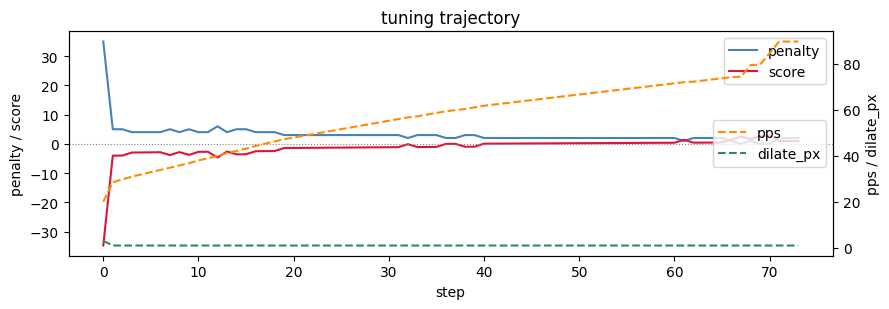

[clean] no bad connections found -> skeleton unchanged (21,012 points)


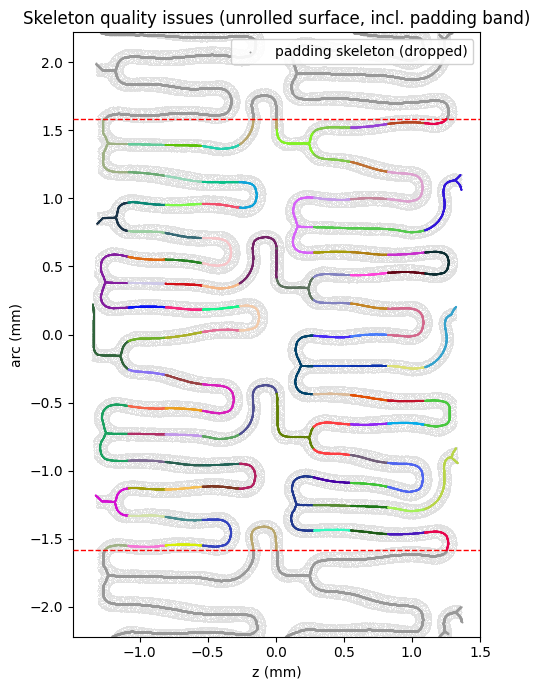

[reconnect] endpoints 8 → 8  (0 bridges added, max_gap = 0.0220 mm, cone = 60°)
[prune_spurs] removed 0 nodes in 0 spur branch(es); remaining non-tip endpoints: 0


In [3]:
STENT_NAME = 'stent4'

STENT_NAME = '2crownCrimpedXienceStent'
#STENT_NAME = '16crownCrimpedXienceStent+extremaSupports'

STENT_STL_FILE = os.path.join(os.path.abspath('../..'), 'input_examples', 'stent_designs', f'{STENT_NAME}.stl')

if STENT_NAME == '16crownCrimpedXienceStent+extremaSupports':
    REMOVE_SUPPORTS = True
    OVERRIDE_N_SAMPLES = None
else:
    REMOVE_SUPPORTS = False
    OVERRIDE_N_SAMPLES = None

SEGMENTATION_WANTED = True   # segment surface into pipe-like regions (drives quality scoring + tuning)
SMALL_LOGIC = 'or'           # 'or' = small by point-count OR bbox-diagonal; 'and' = both

AUTO_TUNE = True             # penalty-driven search of pixels_per_strut / dilate_px
TUNE_TIME_LIMIT = 180.0       # auto-tuning wall-clock cap (s)

PIXELS_PER_STRUT = 20        # raster resolution (start value when AUTO_TUNE)
DILATE_PX = 3             # raster dilation radius (start value when AUTO_TUNE)
PAD_FRACTION = 0.20          # seam-replication margin for the unrolled raster

STENT_DICT = stent_skeleton(
    stent_stl_file      = STENT_STL_FILE,
    auto_tune           = AUTO_TUNE,
    tune_time_limit     = TUNE_TIME_LIMIT,
    pixels_per_strut    = PIXELS_PER_STRUT,
    dilate_px           = DILATE_PX,
    pad_fraction        = PAD_FRACTION,
    override_n_samples  = OVERRIDE_N_SAMPLES,
    segmentation_wanted = SEGMENTATION_WANTED,
    small_logic         = SMALL_LOGIC,
    remove_supports     = REMOVE_SUPPORTS,
    plot_thickness_calc = False,
    plot_segmentation   = False,
    plot_skeleton       = True,
)

In [6]:
# Print a summary of the results
print("\nSummary of results:")
for key, value in STENT_DICT.items():
    if isinstance(value, float) or isinstance(value, int) or isinstance(value, str):
        print(f"{key}: {value:.4f}")
    elif isinstance(value, np.ndarray):
        print(f"{key}: array of shape {value.shape}")
    elif isinstance(value, pd.DataFrame):
        print(f"{key}: DataFrame with shape {value.shape} and columns {value.columns.tolist()}")
        print(f"       Sample data:\n{value.head(50).to_string(index=False)}")
    elif isinstance(value, dict):
        print(f"    {key}: dict")
        for subkey, subvalue in value.items():
            if isinstance(subvalue, float) or isinstance(subvalue, int) or isinstance(subvalue, str):
                print(f"           {subkey}: {subvalue:.4f}")
            elif isinstance(subvalue, np.ndarray):
                print(f"          {subkey}: array of shape {subvalue.shape}")
            else:
                print(f"          {subkey}: {type(subvalue)}")
    else:        
        print(f"{key}: {type(value)}")

# Visualize the final skeleton points in the context of the original scene
skeleton_points = STENT_DICT['skeleton_points_df'][['x', 'y', 'z']].values
stent_points = STENT_DICT['stent_points_df'][['x', 'y', 'z']].values
final_scene = trimesh.Scene([
    trimesh.PointCloud(stent_points, colors=[200, 200, 200, 30]),
    trimesh.PointCloud(skeleton_points, colors=[255, 0, 0, 255], point_size=5.0)
])
final_scene.show()



Summary of results:
    stent_features: dict
           length: 12.8021
           diameter: 4.6884
           radius: 2.3442
           strut_thickness: 0.2744
           z_min: -6.4071
           z_max: 6.3950
           r_inner: 1.9913
           r_outer: 2.2657
           r_mid: 2.1285
           center_cylinder_radius: 0.9963
           num_points: 153360.0000
           n_regions: 93.0000
           conn_radius_3d: 0.1001
stent_centerline_direction: array of shape (3,)
stent_points_df: DataFrame with shape (153360, 7) and columns ['point_id', 'region', 'x', 'y', 'z', 'r', 'theta']
       Sample data:
 point_id  region         x         y         z        r     theta
        0       1 -1.797144  1.217447 -5.922997 2.170692  2.546172
        1       2  2.109820  0.245126  5.764194 2.124012  0.115665
        2       3 -0.575797 -1.909000 -1.792231 1.993947 -1.863741
        3       4 -0.981110 -2.112936  4.651995 2.329609 -2.005507
        4       5 -1.959011 -1.000310  1.743186 2.

In [7]:
STENT_DICT['stent_points_df']

,point_id,region,x,y,z,r,theta
0,0,1,-1.797144,1.217447,-5.922997,2.170692,2.546172
1,1,2,2.109820,0.245126,5.764194,2.124012,0.115665
2,2,3,-0.575797,-1.909000,-1.792231,1.993947,-1.863741
3,3,4,-0.981110,-2.112936,4.651995,2.329609,-2.005507
4,4,5,-1.959011,-1.000310,1.743186,2.199624,-2.669485
...,...,...,...,...,...,...,...
153355,153355,86,1.125114,1.825699,0.899616,2.144542,1.018503
153356,153356,11,0.564156,2.049345,-1.339788,2.125579,1.302164
153357,153357,6,-1.726080,-0.999755,-4.724983,1.994709,-2.616604
153358,153358,9,0.405627,-2.100164,-1.616224,2.138977,-1.380005


In [8]:
STENT_DICT['skeleton_points_df']

,skeleton_point_id,x,y,z,r,theta,node_type,degree,neighbor_ids
0,0,-1.347170,-1.608195,-6.400243,2.097893,-2.268101,line,2,"[1, 7]"
1,1,-1.336621,-1.616655,-6.400243,2.097649,-2.261655,endpoint,1,[0]
2,2,1.611782,-1.345192,-6.400243,2.099377,-0.695485,endpoint,1,[9]
3,3,2.102914,-0.175360,-6.400243,2.110213,-0.083196,endpoint,1,[10]
4,4,1.600059,1.356244,-6.400243,2.097519,0.703111,endpoint,1,[11]
...,...,...,...,...,...,...,...,...,...
16562,16562,-0.111057,-2.101806,6.330539,2.104738,-1.623586,line,2,"[16561, 16563]"
16563,16563,-0.124700,-2.102720,6.344258,2.106414,-1.630031,line,2,"[16562, 16564]"
16564,16564,-0.138129,-2.100028,6.357976,2.104566,-1.636476,line,2,"[16563, 16566]"
16565,16565,-0.165224,-2.098552,6.371695,2.105046,-1.649367,endpoint,1,[16566]


In [9]:
skel_df = STENT_DICT['skeleton_points_df'].reset_index(drop=True)

# Fast coordinate lookup by skeleton_point_id
coords = skel_df.set_index("skeleton_point_id")[["x", "y", "z"]]

# Build unique edge segments from neighbor_ids
segments = []
seen = set()

for _, row in skel_df.iterrows():
    pid = row["skeleton_point_id"]
    p0  = np.array([row["x"], row["y"], row["z"]])
    nbrs = row["neighbor_ids"]
    if isinstance(nbrs, str):
        nbrs = ast.literal_eval(nbrs)
    for nid in nbrs:
        key = (min(pid, nid), max(pid, nid))
        if key in seen or nid not in coords.index:
            continue
        seen.add(key)
        p1 = coords.loc[nid].to_numpy()
        segments.append([p0, p1])

segments = np.array(segments)  # (E, 2, 3)
print(f"Unique edges: {len(segments):,}")

# Separate node types
line_pts     = skel_df[skel_df["node_type"] == "line"][["x", "y", "z"]].to_numpy()
junction_pts = skel_df[skel_df["node_type"] == "junction"][["x", "y", "z"]].to_numpy()

# Bright colors so everything pops against a black background
line_color = np.tile([120, 180, 255, 160], (len(line_pts), 1))  # light-blue line nodes
pc_line    = trimesh.PointCloud(line_pts, colors=line_color)

path = trimesh.load_path(segments)
path.colors = np.tile([120, 180, 255, 220], (len(path.entities), 1))

# Junctions marked as small green squares (small cube markers)
marker_size = 0.2 * STENT_DICT['stent_features']['strut_thickness'] * 2.0
junction_marker = None
if len(junction_pts):
    boxes = []
    for p in junction_pts:
        box = trimesh.creation.box(extents=[marker_size] * 3)
        box.apply_translation(p)
        boxes.append(box)
    junction_marker = trimesh.util.concatenate(boxes)
    junction_marker.visual.face_colors = [0, 255, 0, 255]  # green
print(f"Junctions: {len(junction_pts):,}")

# Endpoints (degree == 1) marked with a big red 3D cross
endpoint_pts = skel_df[skel_df["degree"] == 1][["x", "y", "z"]].to_numpy()
print(f"Endpoints (degree 1): {len(endpoint_pts):,}")

cross_half = 0.2 * STENT_DICT['stent_features']['strut_thickness'] * 5.0  # big, visible arms
cross_segments = []
for p in endpoint_pts:
    for axis in np.eye(3):
        cross_segments.append([p - cross_half * axis, p + cross_half * axis])
cross_segments = np.array(cross_segments)  # (3*N, 2, 3)

scene_parts = [path, pc_line]
if junction_marker is not None:
    scene_parts.append(junction_marker)
if len(cross_segments):
    crosses = trimesh.load_path(cross_segments)
    crosses.colors = np.tile([255, 0, 0, 255], (len(crosses.entities), 1))
    scene_parts.append(crosses)

scene = trimesh.Scene(scene_parts)
# Black background so green junctions, blue lines and red endpoints all stand out
scene.show(background=[0, 0, 0, 255])


Unique edges: 16,782
Junctions: 413
Endpoints (degree 1): 19


In [41]:
#  Output directory 
OUTPUT_DIR = os.path.join(
    os.path.abspath('../..'), 'notebook_outputs', STENT_NAME
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. stent_features → JSON
features_path = os.path.join(OUTPUT_DIR, 'stent_features.json')
with open(features_path, 'w') as f:
    json.dump(
        {k: float(v) if isinstance(v, (np.floating, np.integer)) else v
         for k, v in STENT_DICT['stent_features'].items()},
        f, indent=2
    )
print(f"Saved stent_features        → {features_path}")

# 2. stent_centerline_direction → JSON
direction_path = os.path.join(OUTPUT_DIR, 'stent_centerline_direction.json')
with open(direction_path, 'w') as f:
    json.dump(STENT_DICT['stent_centerline_direction'].tolist(), f, indent=2)
print(f"Saved centerline_direction  → {direction_path}")

# 3. stent_points_df → CSV
stent_csv_path = os.path.join(OUTPUT_DIR, 'stent_points.csv')
STENT_DICT['stent_points_df'].to_csv(stent_csv_path, index=False)
print(f"Saved stent_points_df       → {stent_csv_path}")

# 4. skeleton_points_df → CSV
skeleton_csv_path = os.path.join(OUTPUT_DIR, 'skeleton_points.csv')
STENT_DICT['skeleton_points_df'].to_csv(skeleton_csv_path, index=False)
print(f"Saved skeleton_points_df    → {skeleton_csv_path}")

# 5. skeleton_points_df → STP (STEP AP214 wireframe)
skeleton_stp_path = os.path.join(OUTPUT_DIR, 'skeleton_points.stp')
_write_skeleton_stp(STENT_DICT['skeleton_points_df'], skeleton_stp_path)
print(f"Saved skeleton_points (STP) → {skeleton_stp_path}")


Saved stent_features        → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/notebook_outputs/stent4/stent_features.json
Saved centerline_direction  → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/notebook_outputs/stent4/stent_centerline_direction.json
Saved stent_points_df       → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/notebook_outputs/stent4/stent_points.csv
Saved skeleton_points_df    → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/notebook_outputs/stent4/skeleton_points.csv
Saved skeleton_points (STP) → /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/notebook_outputs/stent4/skeleton_points.stp
